In [1]:
# Add directory above current directory to path
import sys, os; sys.path.insert(0, "..")

from dataset_builder.dataset_builder import DatasetBuilder
from pathlib import Path
import pandas as pd


In [2]:
# Utility functions
def get_model_layer_statistics(dataset_builder, layer_type, file_paths):
    layers, model_names = [], []
    col1, col2 = 'Model Name',  f'Number of {layer_type} Layer'
    for file in file_paths:
        layers.append(len(dataset_builder.read_csv_and_convert_power(file)))
        model_names.append(file.parent.stem)
    df = pd.DataFrame({col1: model_names, col2: layers})
    sorted_df = df.sort_values(by=col2, ascending=False, ignore_index=True)
    display(sorted_df)
    return sorted_df

In [3]:
# Data Configuration

original_model_data_dir_path = Path('../training_data')
pruned_model_data_dir_path = Path('../training_data_pruned')

## Convolutional Layer

In [4]:
from config.convolutional_features import CONV_FEATURES
original_model_conv_files = list(original_model_data_dir_path.rglob("**/convolutional.csv"))
pruned_model_conv_files = list(pruned_model_data_dir_path.rglob("**/convolutional.csv"))

In [5]:
conv_dataset = DatasetBuilder(features=CONV_FEATURES)
original_conv_df = get_model_layer_statistics(conv_dataset, layer_type='Convolutional', file_paths=original_model_conv_files)
pruned_conv_df = get_model_layer_statistics(conv_dataset, layer_type='Convolutional', file_paths=pruned_model_conv_files)

,Model Name,Number of Convolutional Layer
0,lenet,2


,Model Name,Number of Convolutional Layer
0,lenet,2


In [6]:
original_combined_conv_data = conv_dataset.merge_feature_data(original_model_conv_files)

print("Original Model Convolutional Layers data summary")
original_combined_conv_df = pd.concat([original_combined_conv_data.power, original_combined_conv_data.runtime], axis=1)
display(original_combined_conv_df.describe())

Original Model Convolutional Layers data summary


,power,runtime
count,2.000000,2.000000
mean,1.050527,0.221342
std,0.000049,0.028978
min,1.050492,0.200851
25%,1.050510,0.211096
50%,1.050527,0.221342
75%,1.050544,0.231587
max,1.050562,0.241832


In [7]:
pruned_combined_conv_data = conv_dataset.merge_feature_data(pruned_model_conv_files)

print("Pruned Model Convolutional Layers data summary")
pruned_combined_conv_df = pd.concat([pruned_combined_conv_data.power, pruned_combined_conv_data.runtime], axis=1)
display(pruned_combined_conv_df.describe())

Pruned Model Convolutional Layers data summary


,power,runtime
count,2.000000,2.000000
mean,1.039550,0.218209
std,0.000003,0.029167
min,1.039548,0.197584
25%,1.039549,0.207896
50%,1.039550,0.218209
75%,1.039551,0.228521
max,1.039552,0.238833


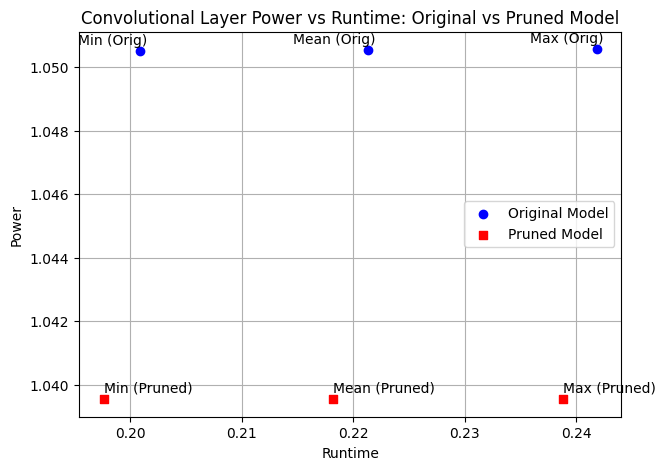

In [8]:
import matplotlib.pyplot as plt

original_mean_values = original_combined_conv_df.mean()
original_min_values = original_combined_conv_df.min()
original_max_values = original_combined_conv_df.max()

pruned_mean_values = pruned_combined_conv_df.mean()
pruned_min_values = pruned_combined_conv_df.min()
pruned_max_values = pruned_combined_conv_df.max()

orig_x = [original_min_values['runtime'], original_mean_values['runtime'], original_max_values['runtime']]
orig_y = [original_min_values['power'], original_mean_values['power'], original_max_values['power']]
orig_labels = ['Min (Orig)', 'Mean (Orig)', 'Max (Orig)']

pruned_x = [pruned_min_values['runtime'], pruned_mean_values['runtime'], pruned_max_values['runtime']]
pruned_y = [pruned_min_values['power'], pruned_mean_values['power'], pruned_max_values['power']]
pruned_labels = ['Min (Pruned)', 'Mean (Pruned)', 'Max (Pruned)']

plt.figure(figsize=(7, 5))

plt.scatter(orig_x, orig_y, color='blue', marker='o', label="Original Model")
for i, label in enumerate(orig_labels):
    plt.annotate(label, (orig_x[i], orig_y[i]), textcoords="offset points", xytext=(5,5), ha='right')

plt.scatter(pruned_x, pruned_y, color='red', marker='s', label="Pruned Model")
for i, label in enumerate(pruned_labels):
    plt.annotate(label, (pruned_x[i], pruned_y[i]), textcoords="offset points", xytext=(0, 5), ha='left')

plt.xlabel("Runtime")
plt.ylabel("Power")
plt.title("Convolutional Layer Power vs Runtime: Original vs Pruned Model")
plt.legend()
plt.grid(True)

plt.show()

# Dense Layer

In [9]:
from config.dense_features import DENSE_FEATURES
original_model_dense_files = list(original_model_data_dir_path.rglob("**/dense.csv"))
pruned_model_dense_files = list(pruned_model_data_dir_path.rglob("**/dense.csv"))

In [10]:
dense_dataset = DatasetBuilder(features=DENSE_FEATURES)
original_dense_df = get_model_layer_statistics(dense_dataset, layer_type='Dense', file_paths=original_model_dense_files)
pruned_dense_df = get_model_layer_statistics(dense_dataset, layer_type='Dense', file_paths=pruned_model_dense_files)

,Model Name,Number of Dense Layer
0,lenet,3


,Model Name,Number of Dense Layer
0,lenet,3


In [11]:
original_combined_dense_data = dense_dataset.merge_feature_data(original_model_dense_files)

print("Original Model Dense Layers data summary")
original_combined_dense_df = pd.concat([original_combined_dense_data.power, original_combined_dense_data.runtime], axis=1)
display(original_combined_dense_df.describe())

Original Model Dense Layers data summary


,power,runtime
count,3.000000,3.000000
mean,1.051091,0.139121
std,0.000164,0.003894
min,1.050976,0.136340
25%,1.050997,0.136896
50%,1.051018,0.137451
75%,1.051148,0.140511
max,1.051279,0.143570


In [12]:
pruned_combined_dense_data = dense_dataset.merge_feature_data(pruned_model_dense_files)

print("Pruned Model Dense Layers data summary")
pruned_combined_dense_df = pd.concat([pruned_combined_dense_data.power, pruned_combined_dense_data.runtime], axis=1)
display(pruned_combined_dense_df.describe())

Pruned Model Dense Layers data summary


,power,runtime
count,3.000000,3.000000
mean,1.039601,0.138323
std,0.000014,0.002442
min,1.039592,0.136374
25%,1.039593,0.136953
50%,1.039594,0.137533
75%,1.039606,0.139297
max,1.039618,0.141062


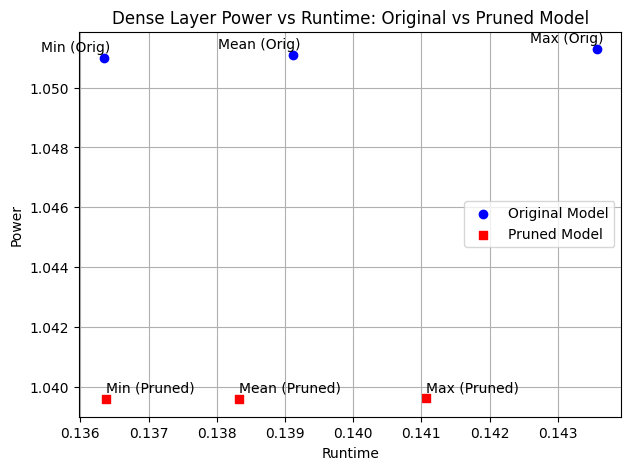

In [13]:
original_mean_values = original_combined_dense_df.mean()
original_min_values = original_combined_dense_df.min()
original_max_values = original_combined_dense_df.max()

pruned_mean_values = pruned_combined_dense_df.mean()
pruned_min_values = pruned_combined_dense_df.min()
pruned_max_values = pruned_combined_dense_df.max()

orig_x = [original_min_values['runtime'], original_mean_values['runtime'], original_max_values['runtime']]
orig_y = [original_min_values['power'], original_mean_values['power'], original_max_values['power']]
orig_labels = ['Min (Orig)', 'Mean (Orig)', 'Max (Orig)']

pruned_x = [pruned_min_values['runtime'], pruned_mean_values['runtime'], pruned_max_values['runtime']]
pruned_y = [pruned_min_values['power'], pruned_mean_values['power'], pruned_max_values['power']]
pruned_labels = ['Min (Pruned)', 'Mean (Pruned)', 'Max (Pruned)']

plt.figure(figsize=(7, 5))

plt.scatter(orig_x, orig_y, color='blue', marker='o', label="Original Model")
for i, label in enumerate(orig_labels):
    plt.annotate(label, (orig_x[i], orig_y[i]), textcoords="offset points", xytext=(5,5), ha='right')

plt.scatter(pruned_x, pruned_y, color='red', marker='s', label="Pruned Model")
for i, label in enumerate(pruned_labels):
    plt.annotate(label, (pruned_x[i], pruned_y[i]), textcoords="offset points", xytext=(0, 5), ha='left')

plt.xlabel("Runtime")
plt.ylabel("Power")
plt.title("Dense Layer Power vs Runtime: Original vs Pruned Model")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
1.051279 / 1.039618

1.0112166199507897